In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
from ALLCools.mcds import MCDS 
import statsmodels.api as sm
from scipy.stats import zscore
from matplotlib.colors import LinearSegmentedColormap
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp
from matplotlib.colors import LinearSegmentedColormap

In [2]:
# Define paths
mcds_path = '../../hazel/gene_mcds/gene'
rna_path = '../../hazel/count_Arab13_with_TEs.csv'
meta_path = '../../hazel/merged_cluster_assignments.csv'

# Load datasets
mcds = MCDS.open(mcds_paths=mcds_path, var_dim='gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index('cell_id')

print(f"Loaded RNA shape: {rna.shape}")
print(f"Loaded Meta shape: {meta.shape}")

Loaded RNA shape: (6071, 64507)
Loaded Meta shape: (5908, 1)


In [3]:
with open('hazel_list.txt', 'r') as file:
    # .strip() removes spaces and \n characters, and we ignore empty lines
    my_gene_list = [line.strip() for line in file if line.strip()]

print(f"Successfully loaded {len(my_gene_list)} genes from hazel_list.txt.")

Successfully loaded 1238 genes from hazel_list.txt.


In [4]:
# Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# Normalize to CPM
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6

# Log1p transformation
rna_log1p = np.log1p(rna_cpm)

# --- Define Stage Merging Map ---
broad_cluster_mapping = {
    3: 'Mesophyll', 0: 'Mesophyll', 7: 'Mesophyll', 1: 'Mesophyll', 10: 'Mesophyll',
    5: 'Epidermis', 4: 'Epidermis', 6: 'Epidermis', 13: 'Epidermis', 8: 'Epidermis',
    14: 'Guard cell', 2: 'Vasculature', 11: 'PPP', 9: 'Phloem', 
    16: 'Myrosinase', 12: 'S phase', 15: 'G2M phase'
}

# Support string and float keys in case index types vary in your metadata
broad_cluster_mapping.update({str(k): v for k, v in broad_cluster_mapping.items()})
broad_cluster_mapping.update({float(k): v for k, v in broad_cluster_mapping.items() if isinstance(k, int)})

# Create a new merged category in the metadata
meta['broad_cluster'] = meta['merged_cluster'].map(broad_cluster_mapping)

# Drop any cells that didn't map successfully (optional but safe)
valid_cells = meta.loc[common_cells][meta.loc[common_cells, 'broad_cluster'].notna()].index

# Aggregate by the NEW merged broad cluster
rna_log1p['cluster'] = meta.loc[valid_cells, 'broad_cluster']
cluster_rna_matrix = rna_log1p.groupby('cluster').mean().T

print(f"Processed RNA matrix shape: {cluster_rna_matrix.shape}")

Processed RNA matrix shape: (64507, 9)


In [8]:
cluster_rna_matrix

cluster,Epidermis,G2M phase,Guard cell,Mesophyll,Myrosinase,PPP,Phloem,S phase,Vasculature
AT1G01010,0.037457,0.123274,0.016309,0.075670,0.103218,0.000000,0.020117,0.178207,0.048096
AT1G01020,0.743411,0.481391,0.221479,0.982423,0.903148,0.203666,0.584201,0.682061,0.576624
AT1G01030,0.154466,0.370302,0.057338,0.247133,0.032590,0.138163,0.165419,0.323830,0.143114
AT1G01040,0.915504,0.920084,0.631241,1.146338,1.413787,1.777067,1.577694,0.619029,1.098356
AT1G01046,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...
ATMG01370,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01375,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01380,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ATMG01390,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [10]:
# Get raw counts (c = methylated, m = total coverage)
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

# Align with valid metadata cells first to ensure indices match
valid_meth_cells = mCGN_mc.index.intersection(meta.index)
mCGN_mc = mCGN_mc.loc[valid_meth_cells]
mCGN_cov = mCGN_cov.loc[valid_meth_cells]

# Use the newly created 'broad_cluster' mapping
mCGN_mc['cluster'] = meta.loc[valid_meth_cells, 'broad_cluster']
mCGN_cov['cluster'] = meta.loc[valid_meth_cells, 'broad_cluster']

# Aggregate counts by cluster
cluster_c = mCGN_mc.groupby('cluster').sum().T  # Shape: (genes, clusters)
cluster_m = mCGN_cov.groupby('cluster').sum().T

# --- 1. Fit Global Offsets (deltas) ---
# Aggregate across all genes per cluster
global_c = cluster_c.sum(axis=0)
global_m = cluster_m.sum(axis=0)
global_p = global_c / global_m

d = logit(np.clip(global_p, 1e-6, 1-1e-6))
deltas = d - np.average(d, weights=global_m)

# --- 2. Calculate Expected Methylation (p0) ---
# Gene-wise baseline (pbar)
gene_c = cluster_c.sum(axis=1)
gene_m = cluster_m.sum(axis=1)

# Mask genes with extremely low total coverage to avoid noise
valid_genes_mask = gene_m >= 50 
cluster_c = cluster_c[valid_genes_mask]
cluster_m = cluster_m[valid_genes_mask]
gene_c = gene_c[valid_genes_mask]
gene_m = gene_m[valid_genes_mask]

pbar = np.clip(gene_c / gene_m, 1e-6, 1-1e-6)

# Broadcast expected values: p0 = expit(logit(pbar) + deltas)
# pbar is (genes,), deltas is (clusters,). We create a (genes, clusters) matrix
logit_pbar = logit(pbar).values[:, None]
expected_logit = logit_pbar + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit), index=cluster_c.index, columns=cluster_c.columns)

# --- 3. Extract Adjusted Matrix ---
# Observed fractions
obs_p = cluster_c / cluster_m.replace(0, np.nan)
obs_p = obs_p.fillna(0) 

# Residuals: observed deviation from the cluster's global logit expectation
adj_meth_matrix = obs_p - p0_df

# Filter for genes that actually have meaningful methylation in at least one cluster
highly_meth_genes = obs_p[obs_p.apply(lambda x: (x >= 0.1).any(), axis=1)].index
filtered_meth_df = adj_meth_matrix.loc[highly_meth_genes]

print(f"Logit-adjusted Methylation matrix shape: {filtered_meth_df.shape}")

Logit-adjusted Methylation matrix shape: (13610, 9)


In [11]:
filtered_meth_df

cluster,Epidermis,G2M phase,Guard cell,Mesophyll,Myrosinase,PPP,Phloem,S phase,Vasculature
gene,,,,,,,,,
AT1G03987,-0.000175,0.110977,-0.014732,-0.003930,-0.011746,-0.013390,0.019183,0.087555,-0.001610
AT1G01040,-0.015856,0.011052,0.060093,0.001921,0.020256,-0.014109,-0.029424,-0.013113,0.040854
AT1G01046,0.014642,0.157904,0.279442,-0.018887,-0.001032,0.068830,-0.140338,0.071834,0.075406
AT1G01050,-0.009256,0.077060,-0.014700,-0.000428,-0.009799,0.022093,0.045463,0.013978,0.006563
AT1G01060,0.002265,0.000287,0.038314,-0.004443,0.013724,0.030159,0.014071,0.006169,0.008565
...,...,...,...,...,...,...,...,...,...
ATMG01400,0.017582,-0.355809,-0.080245,0.063867,0.119294,-0.131360,-0.277515,-0.131422,-0.098287
ATMG01410,0.011203,-0.311277,-0.128146,0.051445,0.013147,0.005410,-0.249865,-0.104440,-0.125312
ATCG00890,-0.019480,-0.021711,-0.022799,0.003770,-0.018208,0.179263,-0.017244,-0.019285,-0.020931


In [31]:
# Align genes across modalities
common_genes = cluster_rna_matrix.index.intersection(filtered_meth_df.index)
final_rna_df = cluster_rna_matrix.loc[common_genes]
final_meth_df = filtered_meth_df.loc[common_genes]

# --- THE FIX: Filter RNA for at least 0.1 log1p CPM in any cluster BEFORE stats ---
rna_expressed_mask = final_rna_df.max(axis=1) >= 0.1
robust_common_genes = final_rna_df[rna_expressed_mask].index

# Update our dataframes to only include these robust genes
final_rna_df = final_rna_df.loc[robust_common_genes]
final_meth_df = final_meth_df.loc[robust_common_genes]
final_weights_df = cluster_m.loc[robust_common_genes]

print(f"Total common genes before filter: {len(common_genes)}")
print(f"Genes remaining for WLS after expression filter: {len(robust_common_genes)}")

correlations = []
p_values = []
valid_genes = []

# Now we loop ONLY over the robust genes
for gene in robust_common_genes:
    rna_vals = final_rna_df.loc[gene].values
    meth_vals = final_meth_df.loc[gene].values
    weight_vals = final_weights_df.loc[gene].values
    
    # Skip genes with zero variance in either modality
    if np.std(rna_vals) == 0 or np.std(meth_vals) == 0:
        continue
        
    # Standardize to make the WLS coefficient behave like a correlation coefficient (Rho)
    rna_z = zscore(rna_vals)
    meth_z = zscore(meth_vals)
    
    # Add constant for intercept
    X = sm.add_constant(meth_z)
    
    try:
        # Fit Weighted Least Squares
        wls_model = sm.WLS(endog=rna_z, exog=X, weights=weight_vals).fit()
        
        rho = wls_model.params[1] 
        p = wls_model.pvalues[1]
        
        valid_genes.append(gene)
        correlations.append(rho)
        p_values.append(p)
    except Exception:
        continue

# Compile statistical results
stats_df = pd.DataFrame({
    'gene': valid_genes,
    'rho': correlations,
    'p_value': p_values
}).set_index('gene')

# Apply FDR correction (Now much more accurate and powerful!)
if len(stats_df) > 0:
    stats_df['fdr'] = multipletests(stats_df['p_value'], method='fdr_bh')[1]
    
    # Now you can just take the top 300 significant ones safely!
    significant_genes = stats_df[stats_df['fdr'] < 0.05]
    top_300_genes = significant_genes.sort_values('rho').head(300).index
    
    print(f"\nFound {len(significant_genes)} statistically significant genes.")
    print("Top 20 negatively correlated genes (WLS, Coverage-Weighted):")
    display(stats_df.loc[top_300_genes].head(20))
else:
    print("WARNING: stats_df is empty!")

Total common genes before filter: 13599
Genes remaining for WLS after expression filter: 9344

Found 41 statistically significant genes.
Top 20 negatively correlated genes (WLS, Coverage-Weighted):


,rho,p_value,fdr
gene,,,
AT1G58290,-1.876507,1.434894e-04,0.036237
AT2G34430,-1.702575,4.616419e-05,0.016591
AT3G60290,-1.658440,3.218510e-05,0.013076
AT3G26290,-1.610655,4.464666e-05,0.016591
AT5G35740,-1.560317,1.075830e-04,0.031332
AT1G51440,-1.528498,1.181413e-04,0.032468
AT5G41761,-1.468118,1.568580e-04,0.038571
AT1G66100,-1.420310,1.237136e-05,0.006800
AT5G52060,-1.395994,2.073623e-05,0.009688


In [32]:
from scipy.stats import median_abs_deviation

def prepare_robust_zscore_fixed(df, genes):
    subset = df.loc[genes]
    
    # Calculate median and MAD
    medians = subset.median(axis=1)
    mads = subset.apply(lambda x: median_abs_deviation(x, scale="normal"), axis=1)
    stds = subset.std(axis=1)
    
    # THE FIX: If MAD is too small (e.g., less than 0.01), fall back to Standard Deviation.
    # This prevents tiny background noise from being divided by ~0 and exploding to +2.5
    scale = np.where(mads < 1e-2, stds, mads)
    
    # Secondary safety: if even STD is basically 0 (gene is totally flat), replace with 1
    scale = np.where(scale < 1e-6, 1, scale)
    
    # Calculate Z-score using the safe scale
    robust_z = subset.subtract(medians, axis=0).div(scale, axis=0)
    
    return robust_z.clip(lower=-2.5, upper=2.5)



Found 32 robust, significant genes.
Plotting top 32 genes with the strongest negative WLS correlation.


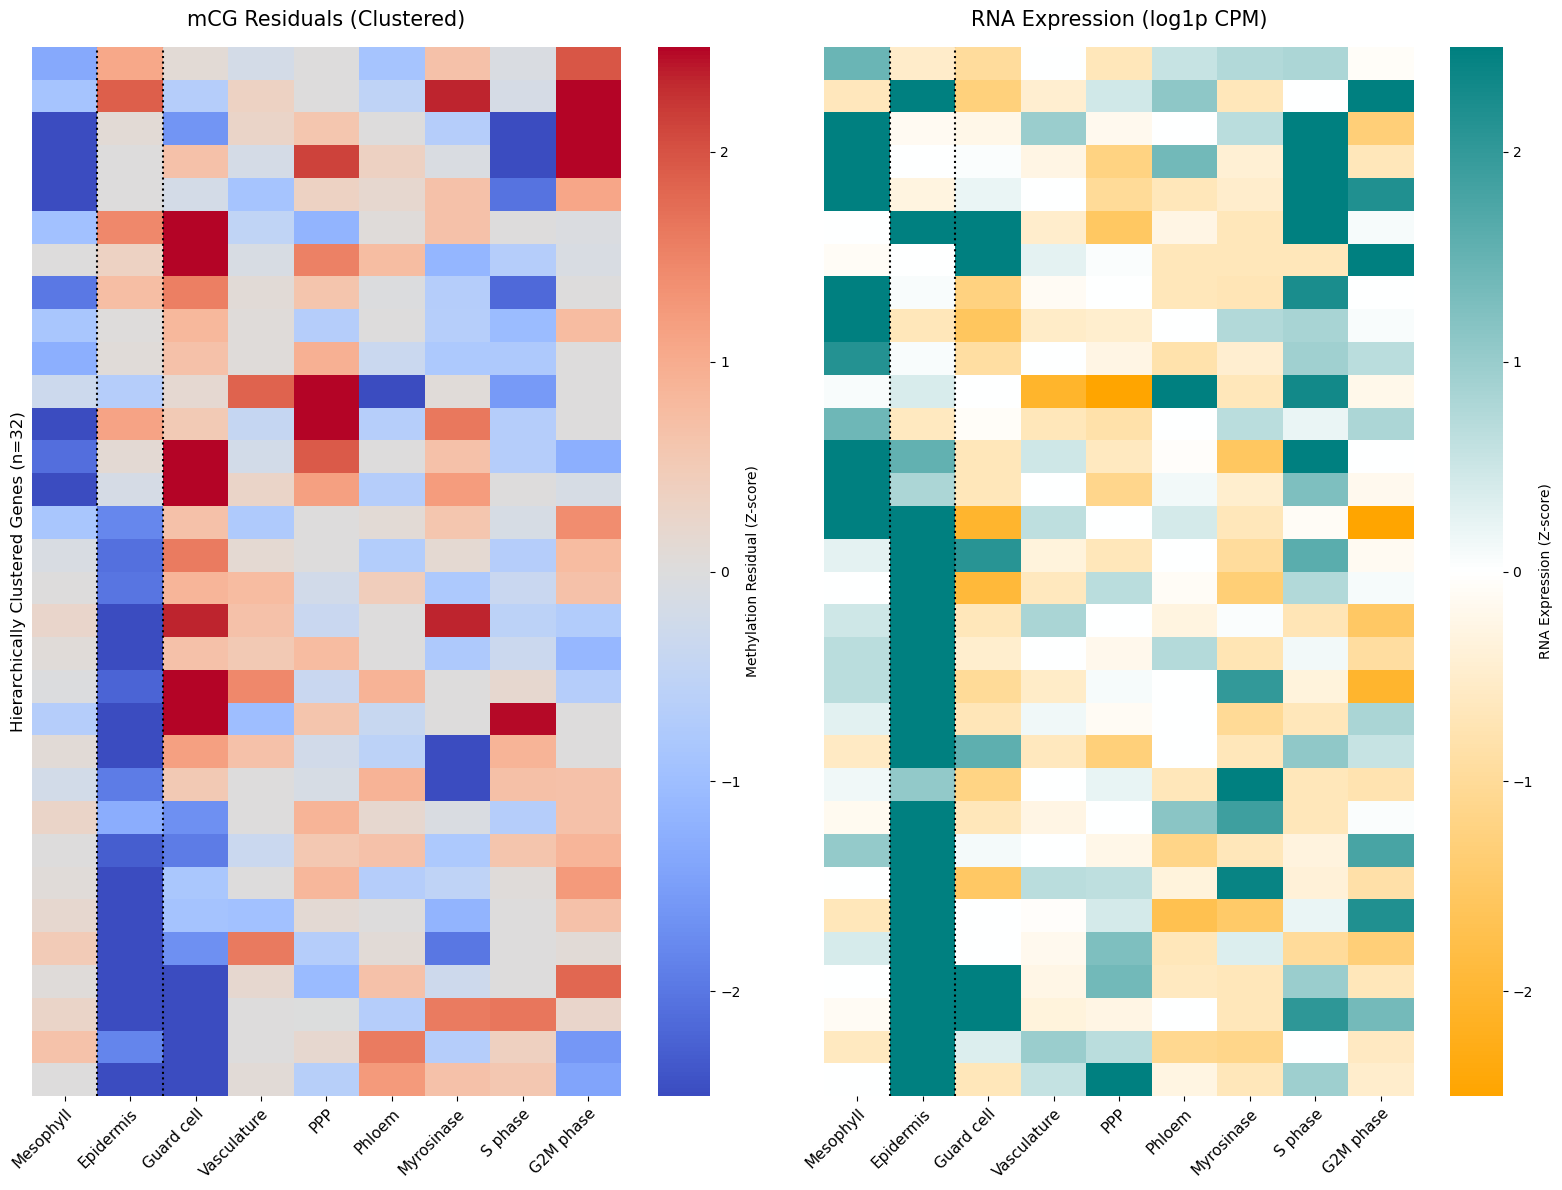

In [33]:
# 1. Define the desired order using the NEW broad categories
cluster_order = [
    'Mesophyll', 'Epidermis', 
    'Guard cell', 'Vasculature', 'PPP', 'Phloem', 
    'Myrosinase', 'S phase', 'G2M phase'
]


# 1. Filter for statistically significant correlations (FDR < 0.05)
significant_genes = stats_df[stats_df['fdr'] < 0.05]

# 2. Filter out genes that are essentially unexpressed everywhere
# (e.g., the max expression in any cluster must be at least 0.5 log1p CPM)
valid_rna_max = final_rna_df.max(axis=1)
expressed_genes = valid_rna_max[valid_rna_max >= 0.5].index

# 3. Intersect and get the true top 300
robust_candidates = significant_genes.loc[significant_genes.index.intersection(expressed_genes)]

top_300_genes = robust_candidates.sort_values('rho').head(300).index

print(f"Found {len(robust_candidates)} robust, significant genes.")
print(f"Plotting top {len(top_300_genes)} genes with the strongest negative WLS correlation.")



# # Get the Top 300 genes from the WLS results
# top_300_genes = stats_df.sort_values('rho').head(300).index
# print(f"Plotting top {len(top_300_genes)} genes with the strongest negative WLS correlation, with robust zscore")

# 2. Data Preparation (Z-scoring)
def prepare_zscore(df, genes):
    subset = df.loc[genes]
    z = subset.apply(zscore, axis=1)
    return z.clip(lower=-2.5, upper=2.5)

# vis_meth_z = prepare_zscore(final_meth_df, top_300_genes)
# vis_rna_z = prepare_zscore(final_rna_df, top_300_genes)

# Then apply it:
vis_meth_z = prepare_robust_zscore(final_meth_df, top_300_genes)
vis_rna_z = prepare_robust_zscore(final_rna_df, top_300_genes)

# 3. Apply Custom Cluster Names and Column Ordering
# (We removed the rename() step since the columns are already named correctly)

# Define the exact names of the clusters you want to exclude
clusters_to_drop = []#["Guard cell", "G2M phase"] 

# Filter the valid_order list to exclude the dropped clusters
valid_order = [
    c for c in cluster_order 
    if c in vis_meth_z.columns and c not in clusters_to_drop
]

vis_meth_sorted = vis_meth_z[valid_order]
vis_rna_sorted = vis_rna_z[valid_order]

# --- 4. Hierarchical Clustering on Genes (Rows) ---
row_linkage = hc.linkage(sp.distance.pdist(vis_meth_sorted.values), method='ward')
row_order = hc.leaves_list(row_linkage)

# Extract the new clustered gene order
clustered_genes = vis_meth_sorted.index[row_order]

# Reorder the rows of both dataframes using this new clustered order
vis_meth_clustered = vis_meth_sorted.loc[clustered_genes]
vis_rna_clustered = vis_rna_sorted.loc[clustered_genes]

# 5. Create custom colormap for RNA (Grey for low, Forest Green for high)
rna_cmap = LinearSegmentedColormap.from_list("Orange_White_Teal", ["orange", "white", "teal"])

# 6. Plotting
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 12), gridspec_kw={'width_ratios': [1, 1]})

# Methylation Heatmap (Coolwarm)
sns.heatmap(vis_meth_clustered, cmap="coolwarm", center=0, ax=ax1, 
            cbar_kws={'label': 'Methylation Residual (Z-score)'}, yticklabels=False)
ax1.set_title("mCG Residuals (Clustered)", fontsize=15, pad=15)
ax1.set_xlabel("")
ax1.set_ylabel(f"Hierarchically Clustered Genes (n={len(top_300_genes)})", fontsize=12)

# --- Anchor the rotated text to the right ---
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
ax1.tick_params(axis='x', labelsize=11)

# RNA Expression Heatmap (Grey to Green)
sns.heatmap(vis_rna_clustered, cmap=rna_cmap, ax=ax2, 
            cbar_kws={'label': 'RNA Expression (Z-score)'}, yticklabels=False)
ax2.set_title("RNA Expression (log1p CPM)", fontsize=15, pad=15)
ax2.set_xlabel("")
ax2.set_ylabel("")

# --- Anchor the rotated text to the right ---
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
ax2.tick_params(axis='x', labelsize=11)

# Add visual dividers dynamically based on the broad category names
divider_positions = []

# Loop through our columns and check for our broad groups
for i, col_name in enumerate(valid_order):
    if col_name == "Mesophyll":
        divider_positions.append(i + 1)
    elif col_name == "Epidermis":
        divider_positions.append(i + 1)

# Draw the lines on both heatmaps
for ax in [ax1, ax2]:
    for pos in divider_positions:
        ax.axvline(pos, color='black', lw=1.5, linestyle=':')

plt.tight_layout()
#plt.savefig("./figures/heatmaps/rna_meth_wls_top300_clustered_heatmap_filtered_1415.svg", format="svg", dpi=300, bbox_inches="tight")
plt.show()

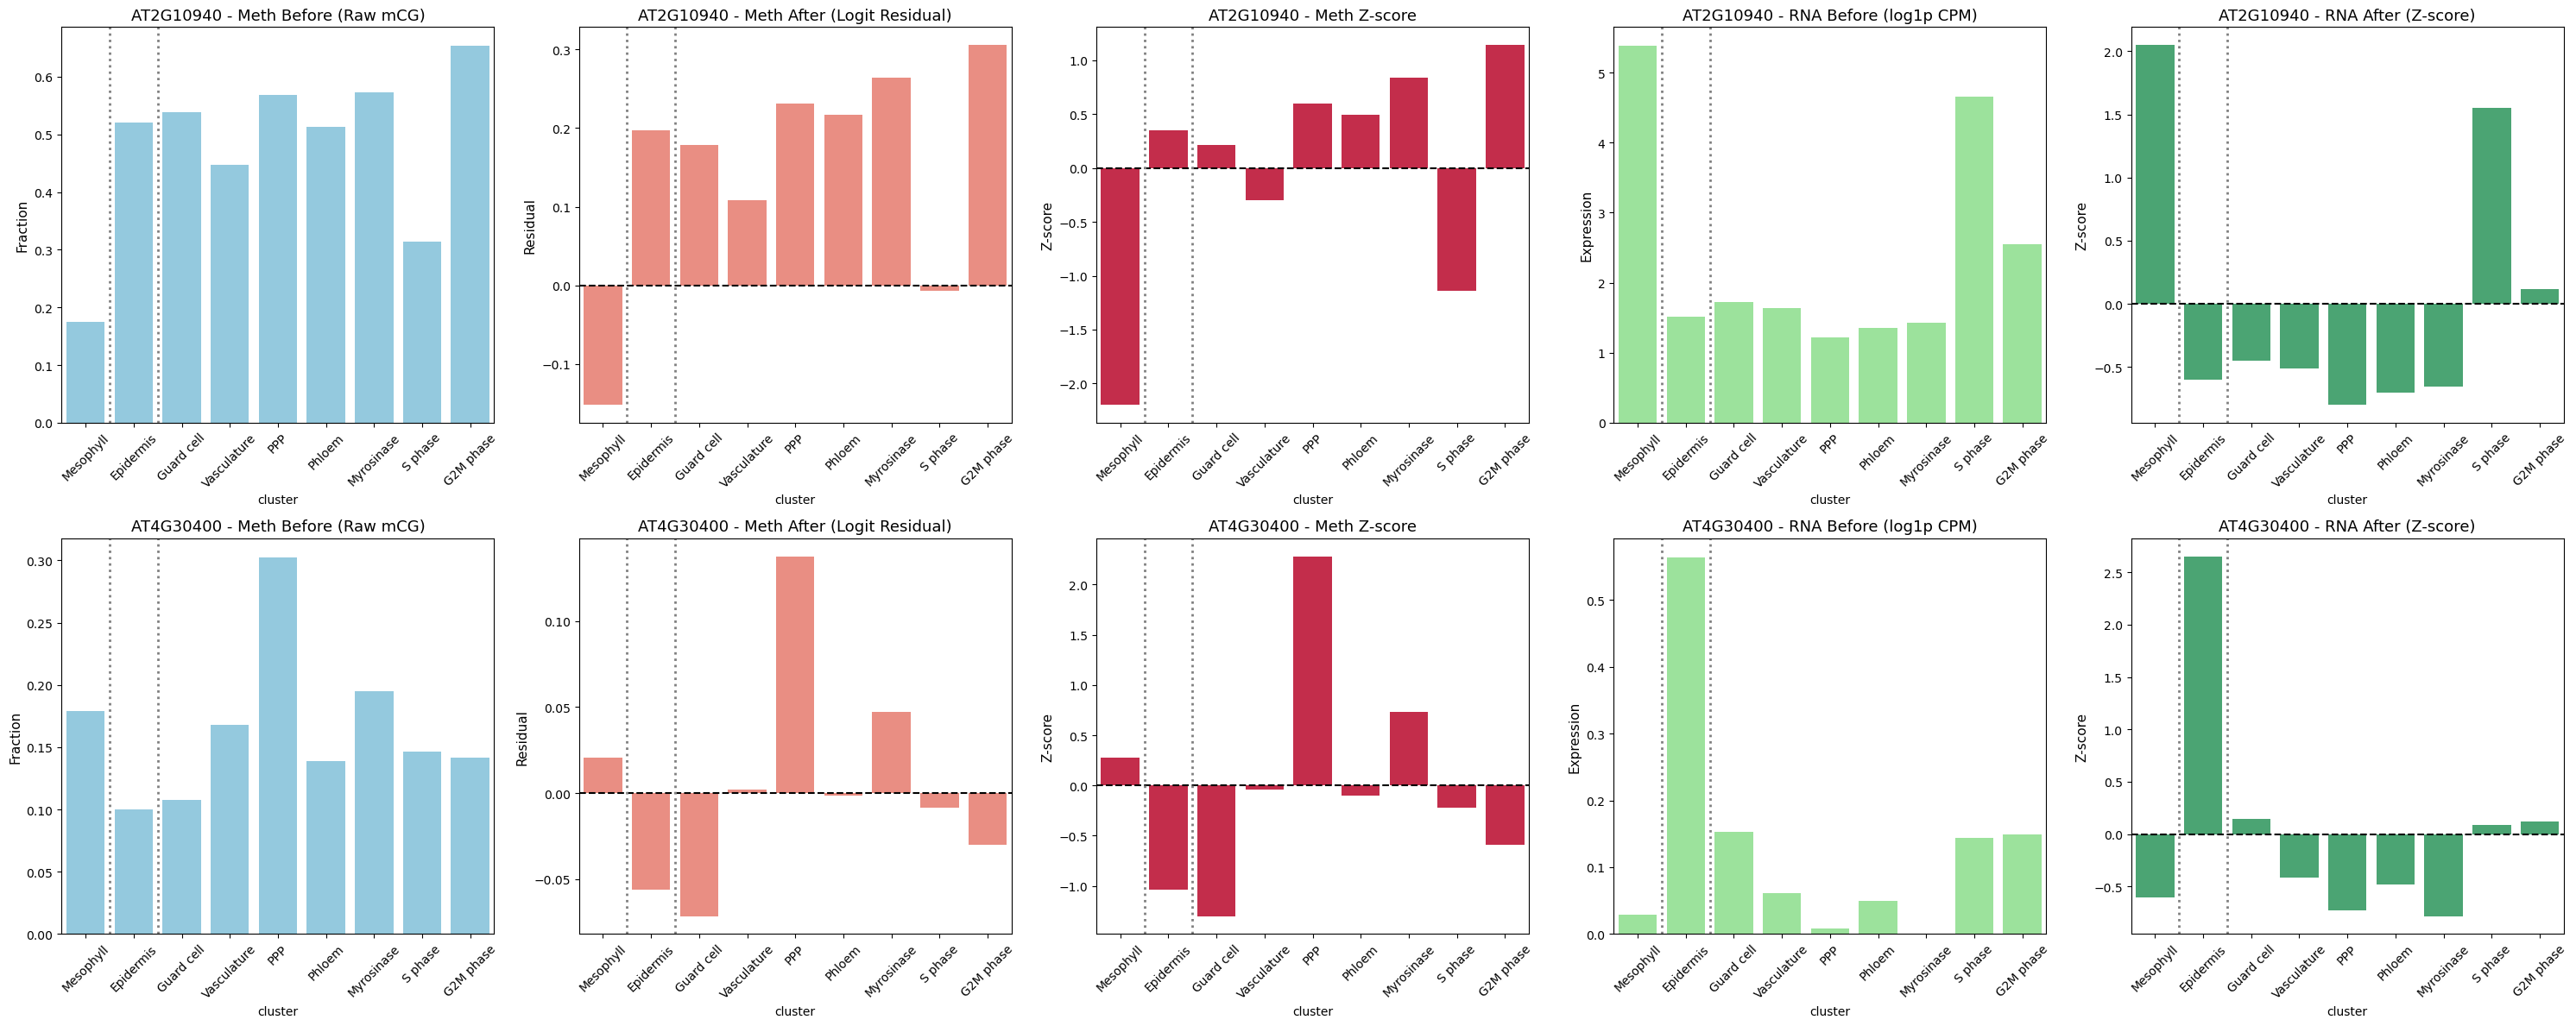

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import zscore
import numpy as np

genes_to_check = ['AT2G10940', 'AT4G30400']

# Define the broad cluster order
cluster_order = [
    'Mesophyll', 'Epidermis', 'Guard cell', 'Vasculature', 
    'PPP', 'Phloem', 'Myrosinase', 'S phase', 'G2M phase'
]

# We now use 5 columns (width increased to 30)
fig, axes = plt.subplots(len(genes_to_check), 5, squeeze=False, figsize=(30, 6 * len(genes_to_check)))

for i, gene in enumerate(genes_to_check):
    # --- Data Extraction & Transformation ---
    has_meth = gene in obs_p.index and gene in adj_meth_matrix.index
    if has_meth:
        meth_raw = obs_p.loc[gene]
        meth_adj = adj_meth_matrix.loc[gene]
        
        # Calculate Meth Z-score on the residual
        meth_z = pd.Series(zscore(meth_adj), index=meth_adj.index)
        
        valid_meth_order = [c for c in cluster_order if c in meth_raw.index]
        meth_raw = meth_raw.reindex(valid_meth_order)
        meth_adj = meth_adj.reindex(valid_meth_order)
        meth_z = meth_z.reindex(valid_meth_order)
        
    has_rna = gene in cluster_rna_matrix.index
    if has_rna:
        rna_raw = cluster_rna_matrix.loc[gene]
        rna_z = pd.Series(zscore(rna_raw), index=rna_raw.index)
        
        valid_rna_order = [c for c in cluster_order if c in rna_raw.index]
        rna_raw = rna_raw.reindex(valid_rna_order)
        rna_z = rna_z.reindex(valid_rna_order)

    # --- Panel 1: Methylation Before ---
    ax1 = axes[i, 0]
    if has_meth:
        sns.barplot(x=meth_raw.index, y=meth_raw.values, ax=ax1, color='skyblue')
        ax1.set_title(f"{gene} - Meth Before (Raw mCG)", fontsize=13)
        ax1.set_ylabel("Fraction", fontsize=11)
    else:
        ax1.set_title(f"{gene} - Meth Data Missing", fontsize=13)
    ax1.tick_params(axis='x', rotation=45)
    
    # --- Panel 2: Methylation After (Residual) ---
    ax2 = axes[i, 1]
    if has_meth:
        sns.barplot(x=meth_adj.index, y=meth_adj.values, ax=ax2, color='salmon')
        ax2.set_title(f"{gene} - Meth After (Logit Residual)", fontsize=13)
        ax2.set_ylabel("Residual", fontsize=11)
        ax2.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax2.tick_params(axis='x', rotation=45)

    # --- Panel 3: Methylation Z-score ---
    ax3 = axes[i, 2]
    if has_meth:
        sns.barplot(x=meth_z.index, y=meth_z.values, ax=ax3, color='crimson')
        ax3.set_title(f"{gene} - Meth Z-score", fontsize=13)
        ax3.set_ylabel("Z-score", fontsize=11)
        ax3.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax3.tick_params(axis='x', rotation=45)

    # --- Panel 4: RNA Before ---
    ax4 = axes[i, 3]
    if has_rna:
        sns.barplot(x=rna_raw.index, y=rna_raw.values, ax=ax4, color='lightgreen')
        ax4.set_title(f"{gene} - RNA Before (log1p CPM)", fontsize=13)
        ax4.set_ylabel("Expression", fontsize=11)
    else:
        ax4.set_title(f"{gene} - RNA Data Missing", fontsize=13)
    ax4.tick_params(axis='x', rotation=45)

    # --- Panel 5: RNA After ---
    ax5 = axes[i, 4]
    if has_rna:
        sns.barplot(x=rna_z.index, y=rna_z.values, ax=ax5, color='mediumseagreen')
        ax5.set_title(f"{gene} - RNA After (Z-score)", fontsize=13)
        ax5.set_ylabel("Z-score", fontsize=11)
        ax5.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax5.tick_params(axis='x', rotation=45)

    # Add vertical dividers to separate Cell Types visually
    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.axvline(0.5, color='gray', linestyle=':', lw=2) # Divider after Mesophyll
        ax.axvline(1.5, color='gray', linestyle=':', lw=2) # Divider after Epidermis

plt.tight_layout()
plt.show()

Plotting top 20 genes...


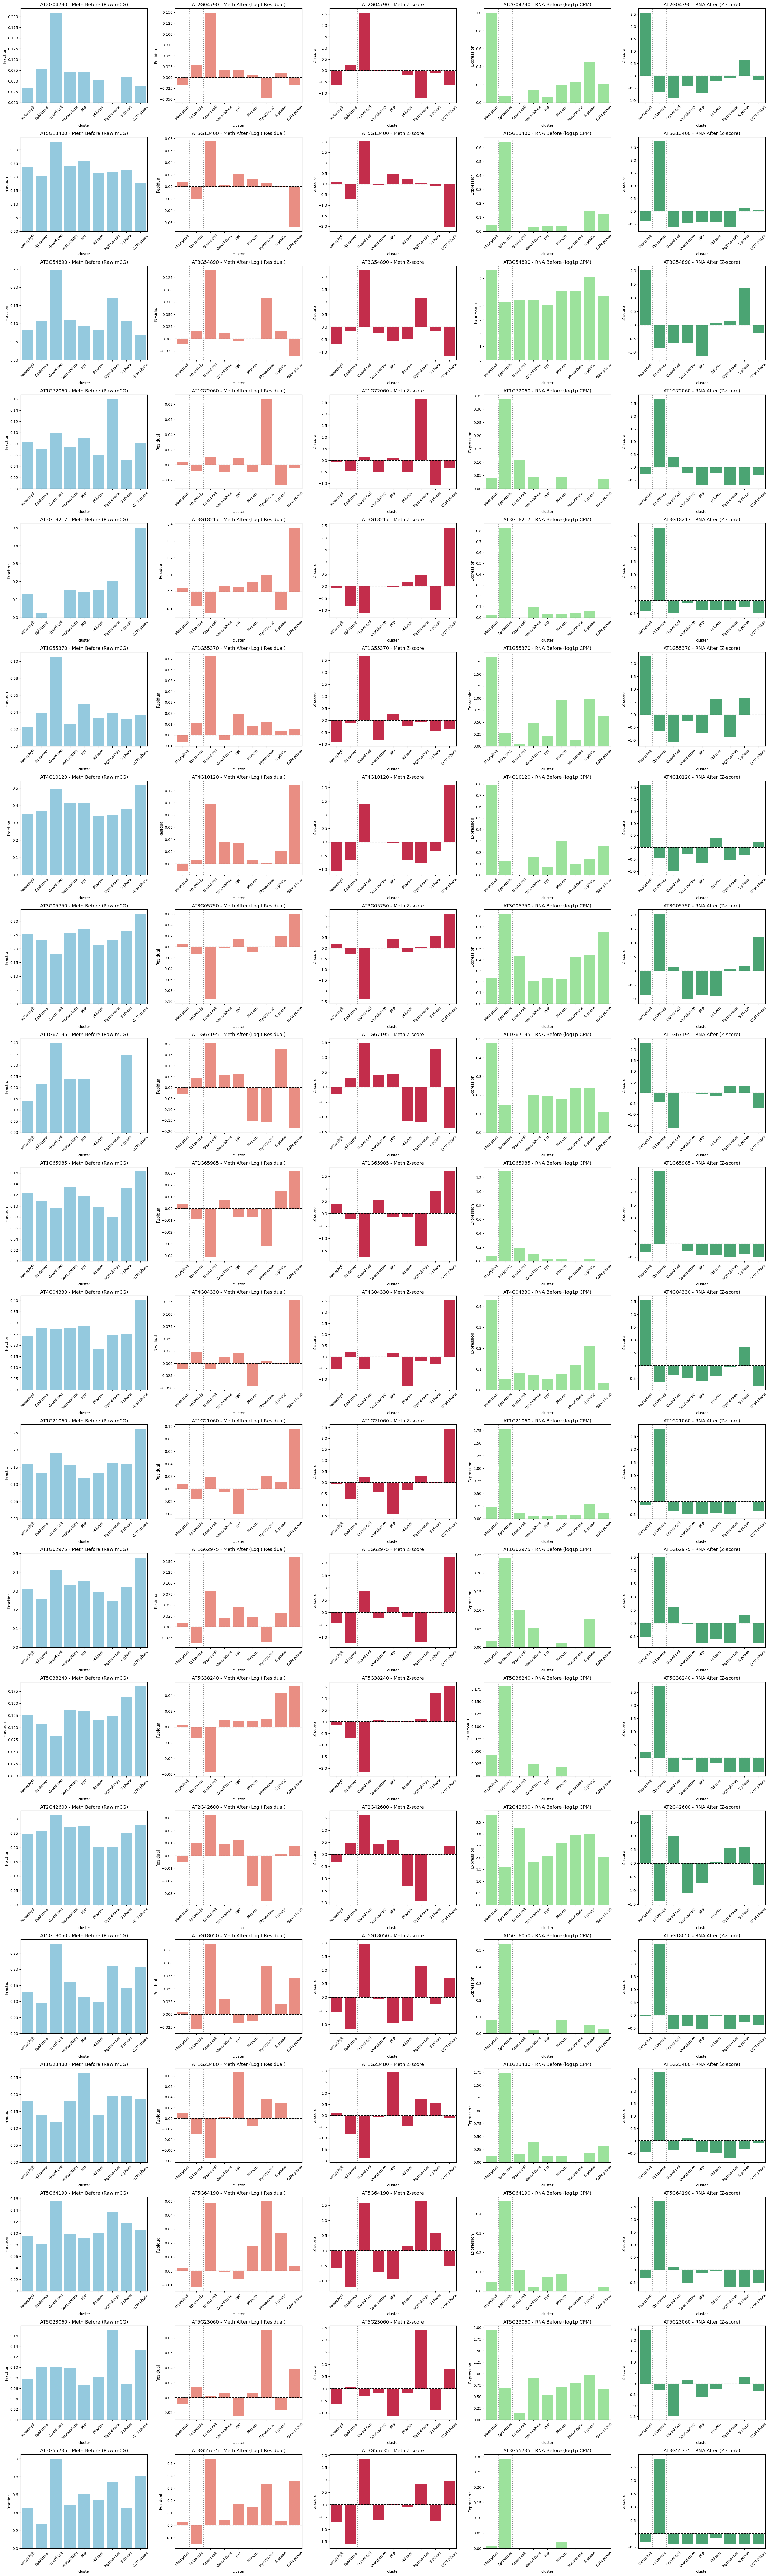

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import zscore
import numpy as np

# --- NEW: Extract the top 20 genes with the strongest negative WLS correlation ---
genes_to_check = stats_df.sort_values('rho').head(20).index.tolist()
print(f"Plotting top {len(genes_to_check)} genes...")

# Define the broad cluster order
cluster_order = [
    'Mesophyll', 'Epidermis', 'Guard cell', 'Vasculature', 
    'PPP', 'Phloem', 'Myrosinase', 'S phase', 'G2M phase'
]

# We use 5 columns. The height scales with the number of genes (5 inches per gene)
fig, axes = plt.subplots(len(genes_to_check), 5, squeeze=False, figsize=(30, 5 * len(genes_to_check)))

for i, gene in enumerate(genes_to_check):
    # --- Data Extraction & Transformation ---
    has_meth = gene in obs_p.index and gene in adj_meth_matrix.index
    if has_meth:
        meth_raw = obs_p.loc[gene]
        meth_adj = adj_meth_matrix.loc[gene]
        
        # Calculate Meth Z-score on the residual
        meth_z = pd.Series(zscore(meth_adj), index=meth_adj.index)
        
        valid_meth_order = [c for c in cluster_order if c in meth_raw.index]
        meth_raw = meth_raw.reindex(valid_meth_order)
        meth_adj = meth_adj.reindex(valid_meth_order)
        meth_z = meth_z.reindex(valid_meth_order)
        
    has_rna = gene in cluster_rna_matrix.index
    if has_rna:
        rna_raw = cluster_rna_matrix.loc[gene]
        rna_z = pd.Series(zscore(rna_raw), index=rna_raw.index)
        
        valid_rna_order = [c for c in cluster_order if c in rna_raw.index]
        rna_raw = rna_raw.reindex(valid_rna_order)
        rna_z = rna_z.reindex(valid_rna_order)

    # --- Panel 1: Methylation Before ---
    ax1 = axes[i, 0]
    if has_meth:
        sns.barplot(x=meth_raw.index, y=meth_raw.values, ax=ax1, color='skyblue')
        ax1.set_title(f"{gene} - Meth Before (Raw mCG)", fontsize=13)
        ax1.set_ylabel("Fraction", fontsize=11)
    else:
        ax1.set_title(f"{gene} - Meth Data Missing", fontsize=13)
    ax1.tick_params(axis='x', rotation=45)
    
    # --- Panel 2: Methylation After (Residual) ---
    ax2 = axes[i, 1]
    if has_meth:
        sns.barplot(x=meth_adj.index, y=meth_adj.values, ax=ax2, color='salmon')
        ax2.set_title(f"{gene} - Meth After (Logit Residual)", fontsize=13)
        ax2.set_ylabel("Residual", fontsize=11)
        ax2.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax2.tick_params(axis='x', rotation=45)

    # --- Panel 3: Methylation Z-score ---
    ax3 = axes[i, 2]
    if has_meth:
        sns.barplot(x=meth_z.index, y=meth_z.values, ax=ax3, color='crimson')
        ax3.set_title(f"{gene} - Meth Z-score", fontsize=13)
        ax3.set_ylabel("Z-score", fontsize=11)
        ax3.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax3.tick_params(axis='x', rotation=45)

    # --- Panel 4: RNA Before ---
    ax4 = axes[i, 3]
    if has_rna:
        sns.barplot(x=rna_raw.index, y=rna_raw.values, ax=ax4, color='lightgreen')
        ax4.set_title(f"{gene} - RNA Before (log1p CPM)", fontsize=13)
        ax4.set_ylabel("Expression", fontsize=11)
    else:
        ax4.set_title(f"{gene} - RNA Data Missing", fontsize=13)
    ax4.tick_params(axis='x', rotation=45)

    # --- Panel 5: RNA After ---
    ax5 = axes[i, 4]
    if has_rna:
        sns.barplot(x=rna_z.index, y=rna_z.values, ax=ax5, color='mediumseagreen')
        ax5.set_title(f"{gene} - RNA After (Z-score)", fontsize=13)
        ax5.set_ylabel("Z-score", fontsize=11)
        ax5.axhline(0, color='black', linewidth=1.5, linestyle='--')
    ax5.tick_params(axis='x', rotation=45)

    # Add vertical dividers to separate Cell Types visually
    for ax in [ax1, ax2, ax3, ax4, ax5]:
        ax.axvline(0.5, color='gray', linestyle=':', lw=2) # Divider after Mesophyll
        ax.axvline(1.5, color='gray', linestyle=':', lw=2) # Divider after Epidermis

plt.tight_layout()
plt.show()

In [37]:
import pandas as pd
from scipy.stats import zscore

gene = 'AT2G04790'

print("=" * 40)
print(f" Detailed Inspection for {gene}")
print("=" * 40 + "\n")

# 1. Check if gene exists in our modalities
has_rna = gene in cluster_rna_matrix.index
has_meth = gene in cluster_m.index and gene in cluster_c.index

print(f"Present in RNA matrix: {has_rna}")
print(f"Present in Methylation matrix: {has_meth}\n")

# --- NEW: Prepare Raw RNA Sums ---
if has_rna:
    # We grab the raw counts directly from rna_aligned and group by the broad clusters
    temp_rna = rna_aligned[[gene]].copy() # Just grab the gene we care about to save memory
    temp_rna['cluster'] = meta.loc[temp_rna.index, 'broad_cluster']
    # Calculate the absolute total number of reads for this gene per cluster
    raw_sums = temp_rna.groupby('cluster')[gene].sum()

# 2. Inspect Methylation Data
if has_meth:
    print("--- 1. Methylation Data (Raw vs Processed) ---")
    
    if gene in adj_meth_matrix.index:
        residual = adj_meth_matrix.loc[gene]
    else:
        residual = pd.Series("Filtered Out", index=cluster_m.columns)

    meth_data = pd.DataFrame({
        'Total_Coverage (m)': cluster_m.loc[gene],
        'Methylated_Counts (c)': cluster_c.loc[gene],
        'Obs_Fraction (p)': obs_p.loc[gene],
        'Expected_Fraction (p0)': p0_df.loc[gene],
        'Residual (adj_meth)': residual
    })
    display(meth_data)
else:
    print("No Methylation data found for this gene.")

# 3. Inspect RNA Data
if has_rna:
    print("\n--- 2. RNA Data ---")
    rna_raw = cluster_rna_matrix.loc[gene] # This is the log1p CPM
    
    # Check for zero variance
    if rna_raw.std() == 0:
        print(f"⚠️ {gene} has ZERO variance in RNA expression (it is flat across all clusters).")
        rna_z = pd.Series(0, index=rna_raw.index)
    else:
        rna_z = pd.Series(zscore(rna_raw), index=rna_raw.index)
        
    rna_data = pd.DataFrame({
        'Total_Raw_Reads (Sum)': raw_sums,  # <-- NEW COLUMN added here
        'log1p_CPM': rna_raw,
        'Z_Score': rna_z
    })
    display(rna_data)

# 4. Check WLS Statistical Results
print("\n--- 3. Statistical Results (WLS) ---")
if 'stats_df' in locals() and gene in stats_df.index:
    display(pd.DataFrame(stats_df.loc[gene]).T)
else:
    print(f"⚠️ {gene} is NOT in the final `stats_df`.")

 Detailed Inspection for AT2G04790

Present in RNA matrix: True
Present in Methylation matrix: True

--- 1. Methylation Data (Raw vs Processed) ---


,Total_Coverage (m),Methylated_Counts (c),Obs_Fraction (p),Expected_Fraction (p0),Residual (adj_meth)
cluster,,,,,
Epidermis,4853,381,0.078508,0.051033,0.027475
G2M phase,101,4,0.039604,0.056670,-0.017066
Guard cell,91,19,0.208791,0.059403,0.149388
Mesophyll,10365,360,0.034732,0.051742,-0.017010
Myrosinase,84,0,0.000000,0.047803,-0.047803
PPP,341,24,0.070381,0.054216,0.016166
Phloem,388,20,0.051546,0.045345,0.006202
S phase,352,21,0.059659,0.050540,0.009119
Vasculature,1380,99,0.071739,0.054703,0.017036



--- 2. RNA Data ---


,Total_Raw_Reads (Sum),log1p_CPM,Z_Score
cluster,,,
Epidermis,1064,0.073588,-0.653575
G2M phase,544,0.207476,-0.188710
Guard cell,0,0.000000,-0.909076
Mesophyll,109497,1.000210,2.563701
Myrosinase,70,0.231824,-0.104173
PPP,6,0.062348,-0.692601
Phloem,810,0.195356,-0.230791
S phase,1183,0.446751,0.642064
Vasculature,1613,0.138891,-0.426838



--- 3. Statistical Results (WLS) ---


,rho,p_value,fdr
AT2G04790,-3.094914,0.001358,0.133611
